## 2-field posthoc binning: errorbar consistency (noise-bias-subtracted)

Two correlated fields, posthoc + direct binned bandpower estimators, with
noise bias subtracted (Eq. 9 of Kvasiuk et al. 2025).

**Fiducial** = band-limited signal + white pixel noise ($N/\omega\cdot I$ per field).
**Sims** draw signal via `synalm` and add pixel-space white noise, so
$C_{\rm true} = C_{\rm fid}$ exactly. The noise bias is subtracted analytically
so the estimator targets the signal spectrum $S$.

Both posthoc (Eq. 24) and direct binned routes are computed per sim.
They should give identical means and errorbars, both consistent with $F_b^{-1}$.

In [1]:
import sys
sys.path.append('./')
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import opt_einsum as oe
from tqdm import tqdm
import fbpca

from utilities import *
from qmlfast import *

### Setup: 2 correlated fields

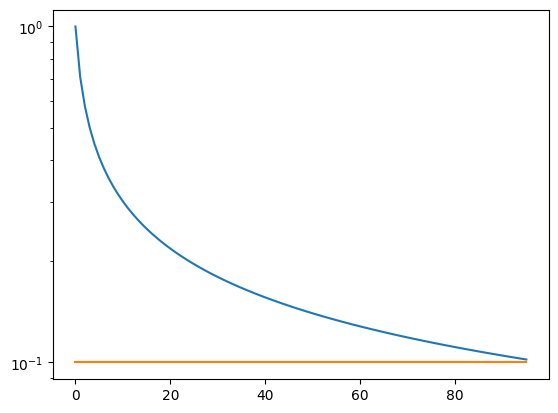

In [2]:
nside = 32
lmax = 3 * nside - 1   # 47
n_ell = 3 * nside      # 48
ell = np.arange(lmax + 1, dtype=float)

S_aa = (ell + 1) ** (-1/2)
S_bb = 3 * (ell + 1) ** (-1/2)
S_ab = 0.5 * np.sqrt(S_aa * S_bb)

N_a = 1e-1
N_b = 1e-1

C_aa = S_aa + N_a
C_bb = S_bb + N_b
C_ab = S_ab       # noise is uncorrelated between fields

Nf = 2
n_pairs = Nf * (Nf + 1) // 2  # 3: (0,0), (0,1), (1,1)
plt.semilogy(ell, S_aa)
plt.semilogy(ell, N_a*np.ones_like(ell))

### Mask

/home/ykvasiuk/miniconda3/envs/pyccl/lib/python3.11/site-packages/healpy/pixelfunc.py:1507: RuntimeWarning: invalid value encountered in _get_neigbors_ring
  r = pixlib._get_neighbors_ring(nside, theta)


Unmasked pixels: 961
Sky fraction: 0.07820638020833333


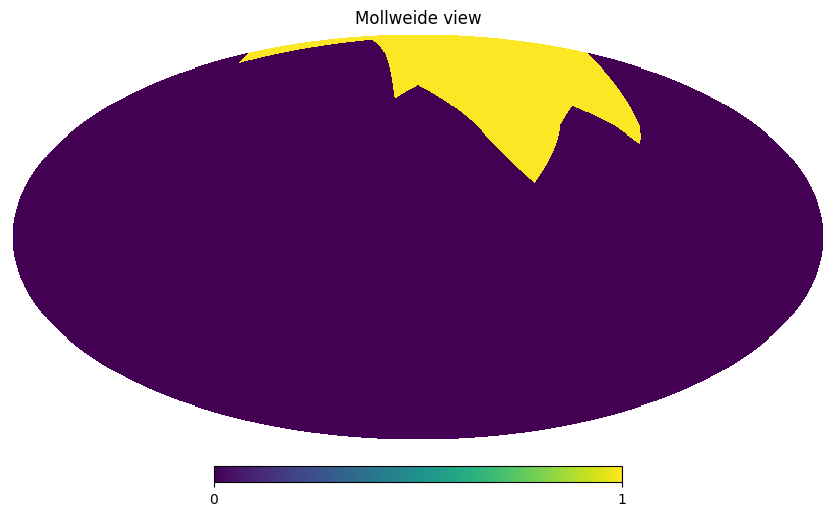

In [3]:
def gen_mask_patch(nside, seed, niter):
    npix = hp.nside2npix(nside)
    idx_bound = seed
    mask = np.zeros(npix)
    mask[seed] = 1
    masks = np.zeros((niter, npix))
    for i in range(niter):
        mask_idx = np.arange(npix)[mask != 0]
        idx = np.unique(hp.get_all_neighbours(nside, idx_bound).flatten())
        mask[idx] = 1
        masks[i] = mask
        idx_bound = np.unique(idx[~np.isin(idx, mask_idx)])
    return masks

masks = gen_mask_patch(nside, 600, 30)
mask = masks[14]
hp.mollview(mask)

theta, phi = theta_phi(nside)
theta = theta[mask == 1]
phi = phi[mask == 1]
Np = int(mask.sum())
omega_pix = 4 * np.pi / hp.nside2npix(nside)
print(f'Unmasked pixels: {Np}')
print(f'Sky fraction: {mask.mean()}')

### Pixel covariance

In [4]:
Pl_ij = get_Pl_ij(theta, phi, nside, lmax=lmax)

def get_pix_cov_block(cl, Pl_ij, lmin, lmax):
    return oe.contract('ijk,i->jk', Pl_ij[lmin:lmax], cl[lmin:lmax])

# Block pixel covariance: signal (band-limited) + white noise (regularizer)
large_cov = np.zeros([Nf * Np, Nf * Np])
large_cov[block_np(0, 0, Np)] = get_pix_cov_block(S_aa, Pl_ij, 0, lmax+1) + np.eye(Np) * N_a / omega_pix
large_cov[block_np(0, 1, Np)] = get_pix_cov_block(S_ab, Pl_ij, 0, lmax+1)
large_cov[block_np(1, 0, Np)] = large_cov[block_np(0, 1, Np)].T
large_cov[block_np(1, 1, Np)] = get_pix_cov_block(S_bb, Pl_ij, 0, lmax+1) + np.eye(Np) * N_b / omega_pix

# Pixel-space noise covariance (block-diagonal, uncorrelated between fields)
N_pix = np.zeros_like(large_cov)
N_pix[block_np(0, 0, Np)] = np.eye(Np) * N_a / omega_pix
N_pix[block_np(1, 1, Np)] = np.eye(Np) * N_b / omega_pix

print(f'cond(C_fid) = {np.linalg.cond(large_cov):.2e}')
Cinv = np.linalg.inv(large_cov)
C_map = np.ones((Nf, Nf))

Pl_ij: 100%|████████████████████████████████████████████████████████| 96/96 [00:00<00:00, 246.26it/s]


cond(C_fid) = 1.95e+01


### Binning matrix: equal-width bins

In [5]:
bin_edges = []
l = 0
delta_ell = 6
while l < n_ell:
    bin_edges.append((l, min(l + delta_ell, n_ell)))
    l += delta_ell

n_bins = len(bin_edges)
P = np.zeros((n_bins, n_ell))
for b, (l_lo, l_hi) in enumerate(bin_edges):
    P[b, l_lo:l_hi] = 1.0 / (l_hi - l_lo)

S_unbin = P.T @ np.linalg.inv(P @ P.T)
ell_eff = np.array([(lo + hi - 1) / 2 for lo, hi in bin_edges])

print(f'Number of bins: {n_bins}')
for b, (lo, hi) in enumerate(bin_edges):
    print(f'  bin {b:2d}: ell = {lo}..{hi-1} (width {hi-lo})')

Number of bins: 16
  bin  0: ell = 0..5 (width 6)
  bin  1: ell = 6..11 (width 6)
  bin  2: ell = 12..17 (width 6)
  bin  3: ell = 18..23 (width 6)
  bin  4: ell = 24..29 (width 6)
  bin  5: ell = 30..35 (width 6)
  bin  6: ell = 36..41 (width 6)
  bin  7: ell = 42..47 (width 6)
  bin  8: ell = 48..53 (width 6)
  bin  9: ell = 54..59 (width 6)
  bin 10: ell = 60..65 (width 6)
  bin 11: ell = 66..71 (width 6)
  bin 12: ell = 72..77 (width 6)
  bin 13: ell = 78..83 (width 6)
  bin 14: ell = 84..89 (width 6)
  bin 15: ell = 90..95 (width 6)


### Per-$\ell$ Fisher matrix

In [6]:
Y_r_all = sph_harm_y_real_all(n_ell, theta, phi)

F_idx_ell = np.array([(i, j, l) for l in range(n_ell)
                       for i in range(Nf) for j in range(i, Nf)])

V_packed_ell, off_ell, rk_ell = pack_sph_harm(Y_r_all)
F_ell = getF_packed(V_packed_ell, off_ell, rk_ell, Cinv, F_idx_ell, Nf, Np, C_map)
print(f'F_ell shape: {F_ell.shape}  '
      f'({n_ell} modes x {n_pairs} pairs = {n_ell * n_pairs})')
print(f'F_ell rank:  {np.linalg.matrix_rank(F_ell)}')

VCinvV: 100%|██████████████████████████████████████████████████████████| 3/3 [00:01<00:00,  1.54it/s]


F_ell shape: (288, 288)  (96 modes x 3 pairs = 288)
F_ell rank:  159


### Analytic binned Fisher: $F_b = \mathcal{S}^T F_\ell \mathcal{S}$

In [7]:
block_P = np.kron(P, np.eye(n_pairs))
block_S = np.kron(S_unbin, np.eye(n_pairs))

F_b = block_S.T @ F_ell @ block_S
inv_Fb = np.linalg.inv(F_b)

PFS = block_P @ F_ell @ block_S
M_posthoc = np.linalg.inv(PFS) @ block_P

M_alt = inv_Fb @ block_S.T
print(f'(PFS)^-1 P  vs  (S^T F S)^-1 S^T : '
      f'rel_err = {np.max(np.abs(M_posthoc - M_alt)) / np.max(np.abs(M_posthoc)):.2e}')
print(f'F_b shape: {F_b.shape}, rank: {np.linalg.matrix_rank(F_b)}')

(PFS)^-1 P  vs  (S^T F S)^-1 S^T : rel_err = 1.66e-16
F_b shape: (48, 48), rank: 48


### Build binned basis via eigendecomposition (direct binned estimator)

In [8]:
Pb_ij = np.einsum('ij,jmn->imn', S_unbin.T, Pl_ij[:n_ell])

V_list = []
for b, (l_lo, l_hi) in enumerate(bin_edges):
    max_rank = min(sum(2*l+1 for l in range(l_lo, l_hi)), Pb_ij.shape[1])
    evals, evecs = fbpca.eigens(Pb_ij[b], k=max_rank)
    order = np.argsort(np.abs(evals))[::-1]
    evals = evals[order[:max_rank]]
    evecs = evecs[:, order[:max_rank]]
    yb = evecs * np.sqrt(np.abs(evals)).reshape(1, -1)
    V_list.append(yb.T)
    print(f'  bin {b:2d} (ell {l_lo:2d}-{l_hi-1:2d}): rank = {V_list[-1].shape[0]}')

V_packed_b, offsets_b, ranks_b = pack_basis(V_list)
F_idx_b = np.array([(i, j, b) for b in range(n_bins)
                     for i in range(Nf) for j in range(i, Nf)])
F_b_direct = getF_packed(V_packed_b, offsets_b, ranks_b, Cinv, F_idx_b, Nf, Np, C_map)
inv_Fb_direct = np.linalg.inv(F_b_direct)

print(f'\nF_b (direct) vs S^T F_ell S:  rel_err = '
      f'{np.max(np.abs(F_b_direct - F_b)) / np.max(np.abs(F_b)):.2e}')

  bin  0 (ell  0- 5): rank = 36
  bin  1 (ell  6-11): rank = 108
  bin  2 (ell 12-17): rank = 180
  bin  3 (ell 18-23): rank = 252
  bin  4 (ell 24-29): rank = 324
  bin  5 (ell 30-35): rank = 396
  bin  6 (ell 36-41): rank = 468
  bin  7 (ell 42-47): rank = 540
  bin  8 (ell 48-53): rank = 612
  bin  9 (ell 54-59): rank = 684
  bin 10 (ell 60-65): rank = 756
  bin 11 (ell 66-71): rank = 828
  bin 12 (ell 72-77): rank = 900
  bin 13 (ell 78-83): rank = 961
  bin 14 (ell 84-89): rank = 961
  bin 15 (ell 90-95): rank = 961


VCinvV: 100%|██████████████████████████████████████████████████████████| 3/3 [00:01<00:00,  2.27it/s]



F_b (direct) vs S^T F_ell S:  rel_err = 4.87e-13


### Noise bias and simulations

$b_A = \tfrac12\,\mathrm{Tr}(C^{-1}P_A C^{-1}\mathbb{N})$ for every index
$A = (\alpha\beta,\ell)$. Signal drawn band-limited; noise added per pixel.

In [ ]:
# Per-ell noise bias: b[A] = (1/2) tr(E_A N) where E_A = C^-1 P_A C^-1
# For multi-field diagonal white noise, use packed basis contractions instead of dense P_l traces.
noise_bias = get_noise_bias_packed_white(
    V_packed_ell, off_ell, rk_ell, Cinv, F_idx_ell, Nf, Np,
    np.array([N_a / omega_pix, N_b / omega_pix]))

# Binned noise bias: b_b = S^T @ b_ell (linearity of tr)
noise_bias_b = block_S.T @ noise_bias

n_sims = 2500
rng = np.random.default_rng(42)

ys_ell = []
ys_bin = []
for i in tqdm(range(n_sims)):
    # Band-limited signal (correlated across fields)
    alm_a, alm_b = hp.synalm([S_aa, S_ab, S_bb], lmax=lmax)
    sig_a = hp.alm2map(alm_a, nside)[mask == 1]
    sig_b = hp.alm2map(alm_b, nside)[mask == 1]
    # Pixel-space white noise (uncorrelated between fields)
    noise_a = rng.normal(0, np.sqrt(N_a / omega_pix), Np)
    noise_b = rng.normal(0, np.sqrt(N_b / omega_pix), Np)
    x = np.stack([sig_a + noise_a, sig_b + noise_b])

    y_ell = get_y_packed(x, V_packed_ell, off_ell, rk_ell,
                         Cinv, F_idx_ell, Nf, Np)
    ys_ell.append(y_ell - noise_bias)

    y_bin = get_y_packed(x, V_packed_b, offsets_b, ranks_b,
                         Cinv, F_idx_b, Nf, Np)
    ys_bin.append(y_bin - noise_bias_b)

ys_ell = np.array(ys_ell)
ys_bin = np.array(ys_bin)
print(f'ys_ell shape: {ys_ell.shape}  ys_bin shape: {ys_bin.shape}')


 34%|████████████████████▌                                        | 841/2500 [04:44<05:16,  5.24it/s]

### Posthoc binning

In [17]:
c_hat_posthoc = ys_ell @ M_posthoc.T
c_mean_posthoc = c_hat_posthoc.mean(axis=0)
c_cov_posthoc = np.cov(c_hat_posthoc, rowvar=False, ddof=1)

### Direct binned

In [18]:
c_hat_direct = ys_bin @ inv_Fb_direct.T
c_mean_direct = c_hat_direct.mean(axis=0)
c_cov_direct = np.cov(c_hat_direct, rowvar=False, ddof=1)

### Fisher-weighted truth (signal only, after noise subtraction)

$\langle\hat c_b\rangle = F_b^{-1} S^T F_\ell\, s$ where $s$ is the per-$\ell$
signal spectrum vector (ordered as F\_idx\_ell).

In [19]:
# Build the per-ell signal vector in F_idx_ell order: (f1, f2, ell)
s_vec = np.zeros(len(F_idx_ell))
S_spectra = {(0,0): S_aa, (0,1): S_ab, (1,1): S_bb}
for a, (f1, f2, l) in enumerate(F_idx_ell):
    s_vec[a] = S_spectra[(f1, f2)][l]

S_true_b = inv_Fb @ (block_S.T @ F_ell @ s_vec)
S_naive_b = block_P @ s_vec

# Also build per-spectrum truth for plotting
spectra_info = [
    (0, 0, S_aa, r'$S_{aa}$'),
    (0, 1, S_ab, r'$S_{ab}$'),
    (1, 1, S_bb, r'$S_{bb}$'),
]

### Errorbar consistency per spectrum

Compare $\sigma_{\rm emp}$ to $\sqrt{\mathrm{diag}\,F_b^{-1}}$ for each
field pair (aa, ab, bb), for both posthoc and direct binned.

In [20]:
ratio_err = 1.0 / np.sqrt(2 * (n_sims - 1))

for fi, fj, S_spec, label in spectra_info:
    idx = (F_idx_b[:, 0] == fi) & (F_idx_b[:, 1] == fj)
    sig_p = np.sqrt(np.diag(c_cov_posthoc)[idx])
    sig_d = np.sqrt(np.diag(c_cov_direct)[idx])
    sig_a = np.sqrt(np.diag(inv_Fb)[idx])

    print(f'\n=== {label} ===')
    print(f'{"bin":>3} {"l_eff":>6} {"post/an":>9} {"dir/an":>9} {"post/dir":>9}')
    for b in range(n_bins):
        print(f'{b:>3d} {ell_eff[b]:>6.1f} '
              f'{sig_p[b]/sig_a[b]:>9.4f} {sig_d[b]/sig_a[b]:>9.4f} '
              f'{sig_p[b]/sig_d[b]:>9.4f}')
    print(f'  mean post/an  = {(sig_p/sig_a).mean():.4f}')
    print(f'  mean dir/an   = {(sig_d/sig_a).mean():.4f}')
    print(f'  mean post/dir = {(sig_p/sig_d).mean():.4f}')


=== $S_{aa}$ ===
bin  l_eff   post/an    dir/an  post/dir
  0    2.5    1.0519    1.0519    1.0000
  1    8.5    1.0396    1.0396    1.0000
  2   14.5    1.0084    1.0084    1.0000
  3   20.5    1.0156    1.0156    1.0000
  4   26.5    1.0058    1.0058    1.0000
  5   32.5    1.0067    1.0067    1.0000
  6   38.5    0.9863    0.9863    1.0000
  7   44.5    1.0154    1.0154    1.0000
  8   50.5    0.9935    0.9935    1.0000
  9   56.5    1.0112    1.0112    1.0000
 10   62.5    0.9912    0.9912    1.0000
 11   68.5    0.9727    0.9727    1.0000
 12   74.5    1.0013    1.0013    1.0000
 13   80.5    0.9986    0.9986    1.0000
 14   86.5    1.0094    1.0094    1.0000
 15   92.5    0.9949    0.9949    1.0000
  mean post/an  = 1.0064
  mean dir/an   = 1.0064
  mean post/dir = 1.0000

=== $S_{ab}$ ===
bin  l_eff   post/an    dir/an  post/dir
  0    2.5    0.9955    0.9955    1.0000
  1    8.5    0.9854    0.9854    1.0000
  2   14.5    0.9631    0.9631    1.0000
  3   20.5    0.9757    0.97

### Comparison plot: posthoc vs direct vs analytic

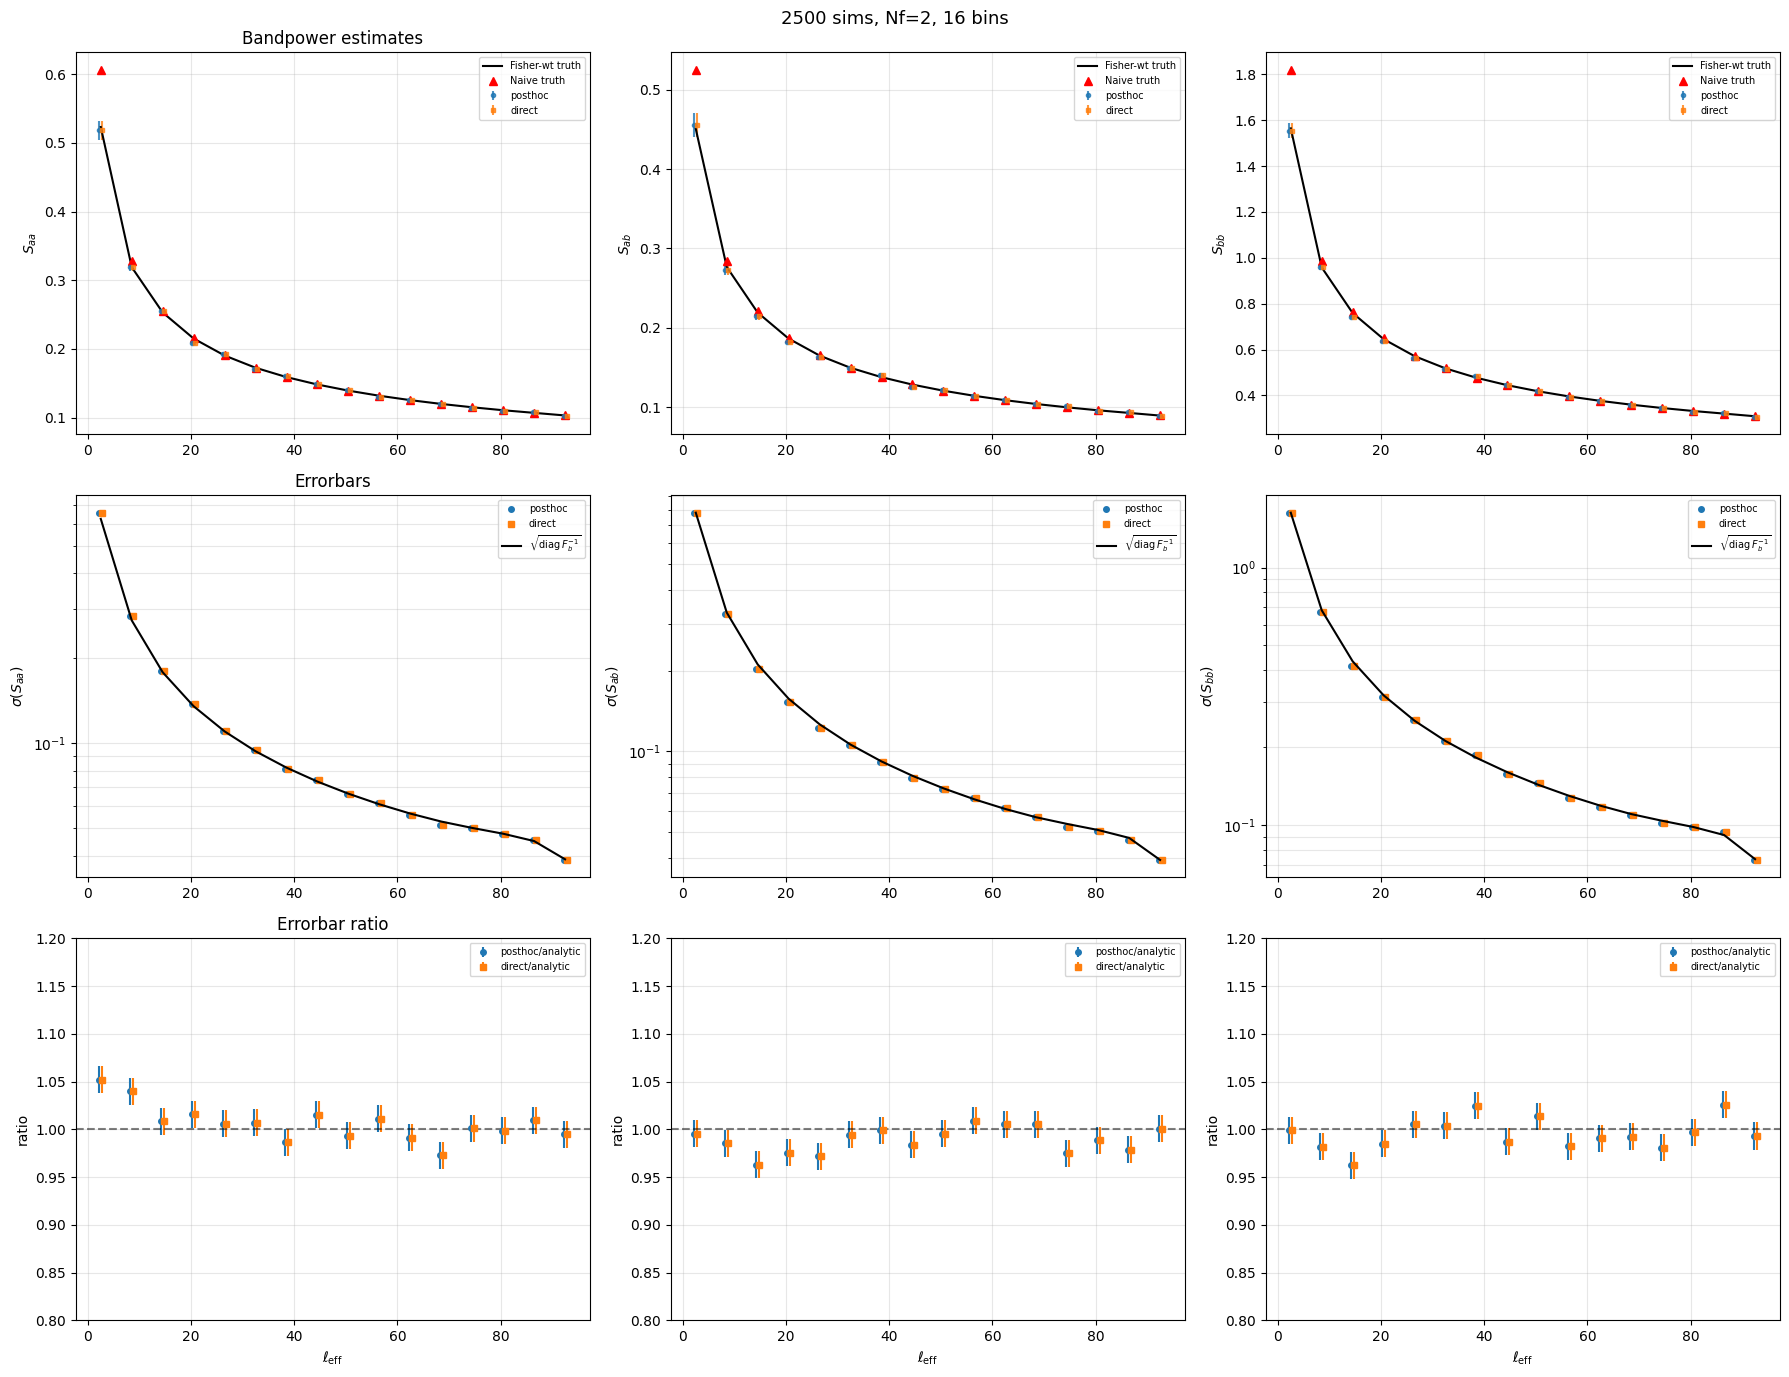

In [21]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
dx = 0.3

for col, (fi, fj, S_spec, label) in enumerate(spectra_info):
    idx = (F_idx_b[:, 0] == fi) & (F_idx_b[:, 1] == fj)

    mean_p = c_mean_posthoc[idx]
    mean_d = c_mean_direct[idx]
    sig_p  = np.sqrt(np.diag(c_cov_posthoc)[idx])
    sig_d  = np.sqrt(np.diag(c_cov_direct)[idx])
    sig_a  = np.sqrt(np.diag(inv_Fb)[idx])
    truth  = S_true_b[idx]
    naive = S_naive_b[idx]
    # Row 0: means
    ax = axes[0, col]
    ax.errorbar(ell_eff - dx, mean_p, yerr=sig_p/np.sqrt(n_sims),
                fmt='o', ms=3, label='posthoc', alpha=0.8)
    ax.errorbar(ell_eff + dx, mean_d, yerr=sig_d/np.sqrt(n_sims),
                fmt='s', ms=3, label='direct', alpha=0.8)
    ax.plot(ell_eff, truth, 'k-', lw=1.5, label='Fisher-wt truth')
    ax.plot(ell_eff, naive, 'r^', lw=1.5, label='Naive truth')

    ax.set_ylabel(label)
    if col == 0: ax.set_title('Bandpower estimates')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

    # Row 1: errorbars
    ax = axes[1, col]
    ax.semilogy(ell_eff - dx, sig_p, 'o', ms=4, label='posthoc')
    ax.semilogy(ell_eff + dx, sig_d, 's', ms=4, label='direct')
    ax.semilogy(ell_eff, sig_a, 'k-', lw=1.5, label=r'$\sqrt{\mathrm{diag}\,F_b^{-1}}$')
    ax.set_ylabel(f'$\sigma$({label})')
    if col == 0: ax.set_title('Errorbars')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3, which='both')

    # Row 2: ratio
    ax = axes[2, col]
    ax.errorbar(ell_eff - dx, sig_p/sig_a, yerr=ratio_err, fmt='o', ms=4,
                label='posthoc/analytic')
    ax.errorbar(ell_eff + dx, sig_d/sig_a, yerr=ratio_err, fmt='s', ms=4,
                label='direct/analytic')
    ax.axhline(1.0, color='k', ls='--', alpha=0.5)
    ax.set_ylabel('ratio')
    ax.set_xlabel(r'$\ell_{\rm eff}$')
    if col == 0: ax.set_title('Errorbar ratio')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)
    ax.set_ylim(0.8, 1.2)

plt.suptitle(f'{n_sims} sims, Nf={Nf}, {n_bins} bins', fontsize=13)
plt.tight_layout()
plt.show()

### Bias check per spectrum

In [23]:
for fi, fj, _, label in spectra_info:
    idx = (F_idx_b[:, 0] == fi) & (F_idx_b[:, 1] == fj)
    mean = c_mean_posthoc[idx]
    truth = S_true_b[idx]
    sig = np.sqrt(np.diag(c_cov_posthoc)[idx])
    std_mean = sig / np.sqrt(n_sims)
    residual = (mean - truth) / std_mean
    rms = np.sqrt(np.mean(residual**2))
    print(f'{label}: RMS residual = {rms:.2f} sigma  ')
    for b in range(n_bins):
        print(f'  bin {b:2d} (l_eff={ell_eff[b]:5.1f}): {residual[b]:+.2f} sigma')

$S_{aa}$: RMS residual = 1.07 sigma  
  bin  0 (l_eff=  2.5): -0.38 sigma
  bin  1 (l_eff=  8.5): +0.11 sigma
  bin  2 (l_eff= 14.5): +0.49 sigma
  bin  3 (l_eff= 20.5): -2.39 sigma
  bin  4 (l_eff= 26.5): +1.27 sigma
  bin  5 (l_eff= 32.5): -0.94 sigma
  bin  6 (l_eff= 38.5): +1.28 sigma
  bin  7 (l_eff= 44.5): +0.16 sigma
  bin  8 (l_eff= 50.5): +0.37 sigma
  bin  9 (l_eff= 56.5): -0.95 sigma
  bin 10 (l_eff= 62.5): +0.15 sigma
  bin 11 (l_eff= 68.5): -0.37 sigma
  bin 12 (l_eff= 74.5): -1.09 sigma
  bin 13 (l_eff= 80.5): -1.05 sigma
  bin 14 (l_eff= 86.5): +1.19 sigma
  bin 15 (l_eff= 92.5): -1.77 sigma
$S_{ab}$: RMS residual = 1.05 sigma  
  bin  0 (l_eff=  2.5): +0.31 sigma
  bin  1 (l_eff=  8.5): -0.52 sigma
  bin  2 (l_eff= 14.5): -1.21 sigma
  bin  3 (l_eff= 20.5): -1.32 sigma
  bin  4 (l_eff= 26.5): -0.65 sigma
  bin  5 (l_eff= 32.5): -0.30 sigma
  bin  6 (l_eff= 38.5): +1.54 sigma
  bin  7 (l_eff= 44.5): -1.86 sigma
  bin  8 (l_eff= 50.5): +0.99 sigma
  bin  9 (l_eff= 56.5): 

### Posthoc / direct errorbar ratio (should be exactly 1)

In [24]:
for fi, fj, _, label in spectra_info:
    idx = (F_idx_b[:, 0] == fi) & (F_idx_b[:, 1] == fj)
    sig_p = np.sqrt(np.diag(c_cov_posthoc)[idx])
    sig_d = np.sqrt(np.diag(c_cov_direct)[idx])
    ratio = sig_p / sig_d
    print(f'{label}: posthoc/direct = {ratio}')

$S_{aa}$: posthoc/direct = [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
$S_{ab}$: posthoc/direct = [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
$S_{bb}$: posthoc/direct = [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
